In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle


fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
extent = [138, 150,-68,-64]

mertz = Region('Mertz',extent)
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [6]:
ds = xr.open_dataset(fname_spira).swap_dims({'n_prof':'time'})
ds = ds.where(
    (ds.lon > extent[0]) &
    (ds.lon < extent[1]) &
    (ds.lat > extent[2]) &
    (ds.lat < extent[3]), drop=True
)

In [7]:
meop=MEOP(extent=extent)
meop.load_profiles_for_spira()

100%|██████████| 84/84 [01:01<00:00,  1.36it/s]


In [8]:
# get new seals data (recorded after Spira cutoff date)
seals = meop.ds.sortby('time').sel(time=slice(ds.time[-1],pd.Timestamp(2026,1,1)))

# filter silly values
seals = seals.where(~((seals.psal < 30) | (seals.psal > 36)))

In [9]:
seals25 = seals.where(seals.pres < 25,drop=True)
seals300 = seals.where(seals.pres < 300,drop=True)

In [10]:
# make sure there is a value above 25dbar
keep = []
for t in seals.time:
    tmp25 = seals25.sel(time=t)
    tmp300 = seals300.sel(time=t)
    boo25 = np.any(~np.isnan(seals25.temp) & ~np.isnan(seals25.psal))
    boo300 = (~np.isnan(seals300.temp) & ~np.isnan(seals300.psal)).sum() > 5
    keep.append(boo25.item() & boo300.item())
print('kept {0} of {1} profiles'.format(np.array(keep).sum(),len(seals.time)))

kept 1698 of 1698 profiles


In [17]:
ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])

/tmp/ipykernel_2552006/1968367709.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])
/tmp/ipykernel_2552006/1968367709.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([ds.drop_duplicates('time'),seals.drop_duplicates('time')])
/tmp/ipykernel_2552006/196836770

In [18]:
ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])
ds['month'] = ds.time.dt.month
ds['year'] = ds.time.dt.year


/tmp/ipykernel_2552006/3670501029.py:1: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop(['longitude','latitude'])


In [19]:
# set up colours
allyears = ds.groupby('time.year').mean().year
colors = plt.cm.tab20(np.linspace(0, 1, len(allyears)))
cdict = dict(zip(allyears.to_numpy(),colors))

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


In [25]:
with open('c3data.pkl', 'wb') as file:
    pickle.dump(ds, file)

In [26]:
with open('cdict.pkl', 'wb') as file:
    pickle.dump(cdict, file)

In [15]:
ds_shelf = ds.where(ds.elevation > -1000,drop=True)

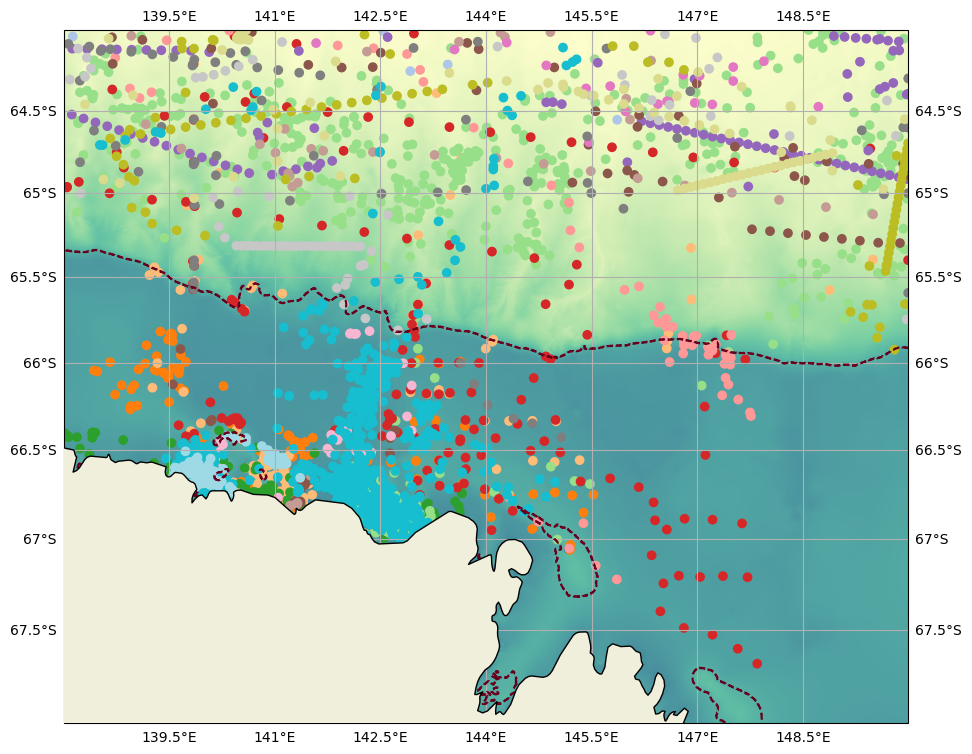

In [16]:
# location map
fig,ax=plt.subplots(figsize=(14,9),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep)
im2=ax.scatter(ds.lon,ds.lat,c=ds.color,transform=ccrs.PlateCarree())#,cmap='tab20')
elevation.plot.contour(ax=ax,levels=[-1000],transform=ccrs.PlateCarree())


In [18]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2005,2026,1)
ally = xr.DataArray(cols, coords={'year':cols})

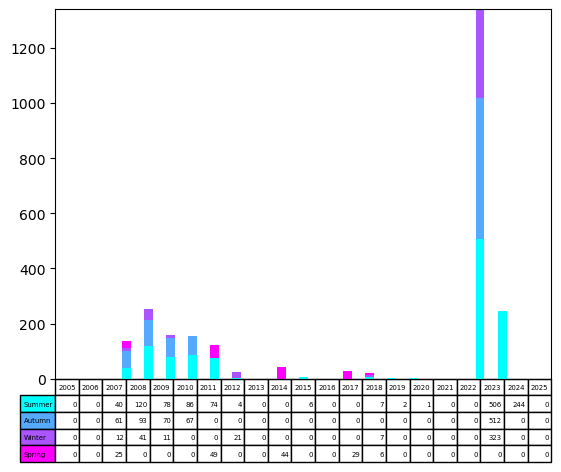

In [19]:
prep4table = lambda season: seasons[season].groupby('time.year').count().month.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    barc = plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])
    y_offset = y_offset + data[row]

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')





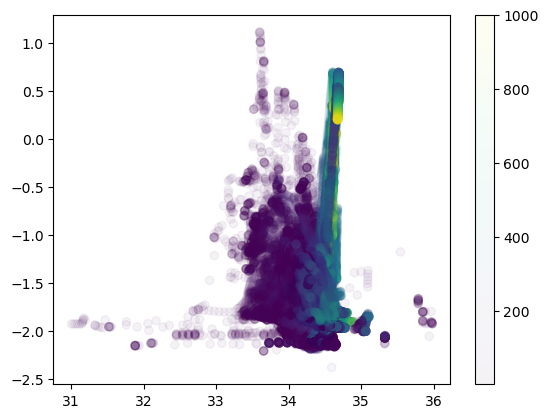

In [20]:
fig, ax = plt.subplots(1,1)
# shapes=['o','s','*','D']
# for s,c in zip(seasons,shapes):
im=ax.scatter(ds_shelf.psal,ds_shelf.temp,alpha=0.05,c=ds_shelf.pres.broadcast_like(ds_shelf.time))
bar=plt.colorbar(im)

KeyError: "No variable named 'sigma0'. Variables on the dataset include ['temp', 'psal', 'dsource', 'mld', 'asal', ..., 'time', 'pres', 'lon', 'lat', 'n_prof']"

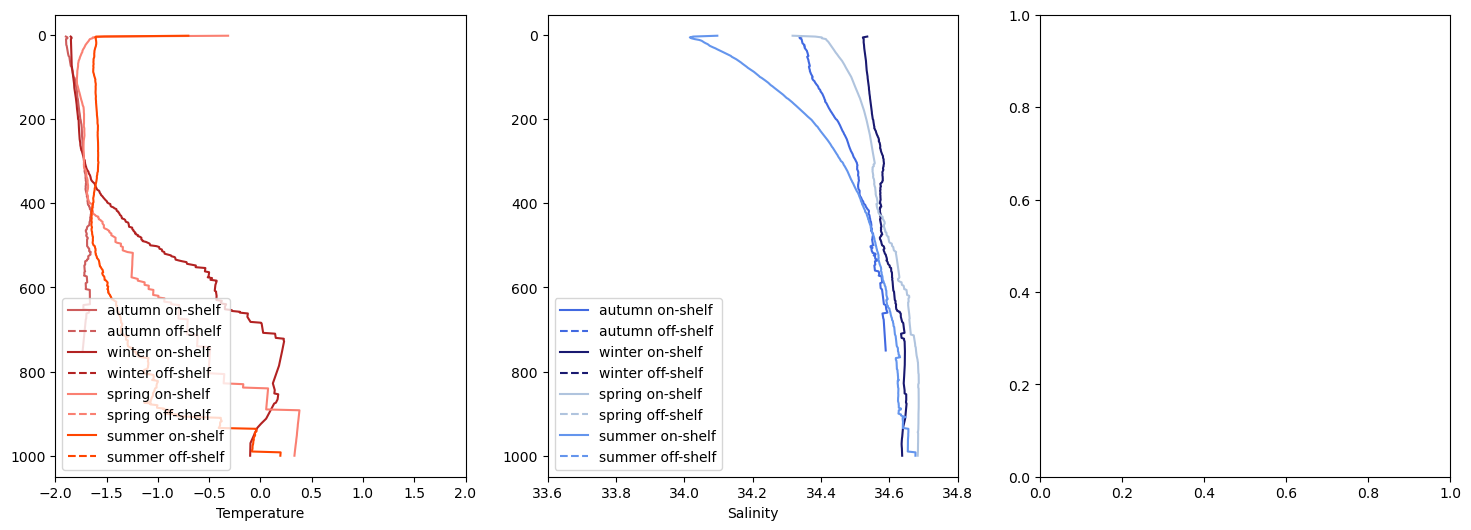

In [21]:
fig, ax = plt.subplots(1,3,figsize=(18,6))
def plot_var(ax,var,title,c,ylim):
    for i,s in enumerate(seasons):
        #get onslope profile
        data=seasons[s].where(seasons[s].elevation > -1000,drop=True)[var].mean('time')
        ax.plot(data,data.pres,'-',c=c[i],label=s + ' on-shelf')
        #get offslope profile
        data=seasons[s].where(seasons[s].elevation < -1000,drop=True)[var].mean('time')
        ax.plot(data,data.pres,'--',c=c[i],label=s+' off-shelf')
    ax.invert_yaxis()
    ax.set_xlim(ylim)
    ax.set_xlabel(title)
    ax.legend(loc='lower left')



plot_var(ax[0],'temp','Temperature',['indianred','firebrick','salmon','orangered'],[-2,2])
plot_var(ax[1],'psal','Salinity',['royalblue','midnightblue','lightsteelblue','cornflowerblue'],[33.6,34.8])
plot_var(ax[2],'sigma0','Density',['mediumvioletred','darkmagenta','plum','violet'],[1027,1027.9])



In [ ]:
# some example sections